In [1]:
# initialization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import time
import threading

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, TextIteratorStreamer
from transformers import LlamaForCausalLM, LlamaTokenizerFast
import transformers

from torch import nn
from typing import Dict, Iterable, Callable
from torch import optim

from torch.utils.tensorboard import SummaryWriter

from datasets import load_dataset
import pickle

device='cuda:0'
tokenizer = LlamaTokenizerFast.from_pretrained('meta-llama/Llama-2-7b-chat-hf')
tokenizer.add_special_tokens({'pad_token': '[PAD]'})


1

In [2]:
# #download and cache dataset

# dataset=load_dataset('oscar', 'unshuffled_deduplicated_en',streaming=True)

# data=[]
# i=0
# for (i,d) in enumerate(dataset['train']):
#     if i==100000: break;
#     data.append(d)

# with open('oscar_en_100.pkl', 'wb') as f: pickle.dump(data, f)
# with open('oscar_en_100k.pkl', 'wb') as f: pickle.dump(data, f)

In [3]:
# dataset class

class Dataset(torch.utils.data.Dataset):
    def __init__(self, dataset_path):
        global paths
        global epoch
        with open(dataset_path, 'rb') as f: self.data=pickle.load(f)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, i):
        line=self.data[i]['text'][0:5000]
        batch  = tokenizer(line, max_length=1024, padding='max_length', truncation=True)
        batch['input_ids']=torch.tensor(batch['input_ids'])
        batch['attention_mask']=torch.tensor(batch['attention_mask'])
        batch['input_ids'][batch['input_ids']==32000]=2
        return batch

# dataset = Dataset('oscar_en_100.pkl')
dataset = Dataset('oscar_en_100k.pkl')

# test dataset class
# line=dataset.data[0]['text'][0:5000]
# batch  = tokenizer(line, max_length=1024, padding='max_length', truncation=True)

In [4]:
# load llama model
model = LlamaForCausalLM.from_pretrained('meta-llama/Llama-2-7b-chat-hf',torch_dtype=torch.float16,device_map=device)
print(type(model))
#display(model)

# quick test of the model
# s= 'We are computer scientists living in'

# pipeline = transformers.pipeline(
#     "text-generation",
#     model=model,
#     torch_dtype=torch.float16,
#     device_map="auto",
#     tokenizer=tokenizer,
# )

# sequences = pipeline(
#     s,
#     do_sample=True,
#     top_k=5,
#     num_return_sequences=1,
#     eos_token_id=tokenizer.eos_token_id,
#     max_length=100,
# )
# for seq in sequences:
#     print(f"Result: {seq['generated_text']}")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

<class 'transformers.models.llama.modeling_llama.LlamaForCausalLM'>


In [10]:
# sequential version
device0='cuda:3'
# recorder = GradRecorder(model,verbose=False)
model=model.to(device0)

In [11]:
class GradRecorder():
    def __init__(self, model: nn.Module, verbose=False):
        global config
        layers=[]
        self.dic=dict([*model.named_modules()])
        for layer_id in self.dic:
            if isinstance(self.dic[layer_id], nn.Linear):# and self.dic[layer_id].in_features<10000 and self.dic[layer_id].out_features<10000 :
                layers.append(layer_id)
                
        self.model = model
        self.layers = layers
        self._activations = {layer: torch.empty(0) for layer in layers}
        self._grads       = {layer: torch.empty(0) for layer in layers}
        
        if verbose: print('registered layers:')
        for layer_id in layers:
            layer = dict([*self.model.named_modules()])[layer_id]
            layer.register_full_backward_hook(self.record_grads_hook      (layer_id))
            layer.register_forward_hook      (self.record_activations_hook(layer_id))
            if verbose: print(self.dic[layer_id].in_features,'x',self.dic[layer_id].out_features,' ',  layer_id)

        self.counter=0
             
    def record_activations_hook(self, layer_id: str) -> Callable:
        def fn(_, input, __):
            self._activations[layer_id] = input[0]
        return fn

    def record_grads_hook(self, layer_id: str) -> Callable:
        def fn(_, __, output):
            self._grads[layer_id] = output[0]
        return fn

    def step(self,layer_id):
#         global allgrads
#         global allacts
          
        inputs     =self._activations[layer_id].detach()
#         outputsgrad=self._grads      [layer_id].detach()
#         inputs=inputs.reshape(-1,inputs.shape[2])
#         outputsgrad=outputsgrad.reshape(-1,outputsgrad.shape[2])
#         allgrads.append(outputsgrad.detach().cpu().numpy())#.astype(np.float16)


#         allacts .append(compress_emb(inputs))        
        self.counter+=1
        return inputs
    
def get_llama_output_embeddings(model,recorder,input_ids,emb):
    with torch.no_grad():
        output=model.forward(input_ids,return_dict=True,use_cache=False,output_hidden_states=False)
        emb[0]=recorder.step('lm_head')
#     return emb


In [13]:

# experiment_name='test13_lr=0.00002'
# writer = SummaryWriter('logs_token_overloading/%s'%(experiment_name) )



loader = torch.utils.data.DataLoader(dataset, batch_size=4, shuffle=False)
loop=tqdm(loader, leave=True)
for (i,batch) in enumerate(loop):
    
    input_ids      = batch['input_ids'     ].to(device)
    attention_mask = batch['attention_mask'].to(device)

    with torch.no_grad():
        output=model.forward(input_ids,return_dict=True,use_cache=False,output_hidden_states=False)

    break



  0%|                                                 | 0/25000 [00:00<?, ?it/s]


In [19]:
torch.argsort(output['logits'][0,1], descending=True)

tensor([ 5086, 13703,  4992,  ...,  1515, 20758, 23767], device='cuda:3')

In [27]:
input_ids[0,:0+1]

tensor([1], device='cuda:3')

In [25]:
tokenizer.decode(input_ids[0,0])

'<s>'

In [21]:
tokenizer.decode([5086, ])

'aking'

In [7]:
torch.max(output['logits'], 2, keepdims=True).values.shape

torch.Size([4, 1024, 1])

In [8]:
# Changing the code changes the style that it is printed with
# the ;2 part seems to be related to rgb values that you pass
#      Note: It may not always be rgb, if the color format 
#            changes for example
def rgb_font(text, r, g, b):
    return f"\x1b[38;2;{r};{g};{b}m{text}\x1b[0m"
def rgb_bg(text, r, g, b):
    return f"\x1b[48;2;{r};{g};{b}m{text}\x1b[0m"
def visualize_next_word(output, input_ids, start, end, top_k):
    for i in range(start, end):
        print(f"================ ITERATION {i} ================")
        tokens=tokenizer.convert_ids_to_tokens(input_ids[0,0:i])
        print(f"Phrase: \t{tokenizer.decode(input_ids[0,0:i])}")
        print("Next word predictions:")
        logits=torch.exp(output['logits'])[0,i,:]
        top_k_ind = torch.argsort(-logits)[:top_k]
        probs = torch.softmax(logits[top_k_ind]/100000, 0)
        decoded_token = tokenizer.convert_ids_to_tokens(top_k_ind)
        decoded_str = [tokenizer.convert_tokens_to_string([t]) for t in decoded_token]
        for ind, next_str, p in zip(top_k_ind, decoded_str, probs):
            if ind != input_ids[0, i+1]:
                print(f"\t{ind}\t", rgb_bg(next_str, 255, int((250)*(1-p)), int((250)*(1-p))), "\t", logits[ind]/100000,p)
            else:
                print(f"\t{ind}\t", rgb_bg(next_str, int((250)*(1-p)), 255, int((250)*(1-p))), "\t", logits[ind]/100000,p)

In [9]:
# Changing the code changes the style that it is printed with
# the ;2 part seems to be related to rgb values that you pass
#      Note: It may not always be rgb, if the color format 
#            changes for example
def rgb_font(text, r, g, b):
    return f"\x1b[38;2;{r};{g};{b}m{text}\x1b[0m"
def rgb_bg(text, r, g, b):
    return f"\x1b[48;2;{r};{g};{b}m{text}\x1b[0m"
def pad(string, length):
    return string + (" "*(length - len(string)))

def visualize_next_word_2(output, input_ids, start, end, top_k):
    column_width = 0
    columns = []
    for i in range(start, end):
        next_word = tokenizer.decode(([input_ids[0,i+1]]))
        
        # Next word predictions:
        logits=torch.exp(output['logits'])[0,i,:]
        top_k_ind = torch.argsort(-logits)[:top_k]
        probs = torch.softmax(logits[top_k_ind]/10000000, 0)
        decoded_token = tokenizer.convert_ids_to_tokens(top_k_ind)
        decoded_str = [tokenizer.convert_tokens_to_string([t]) for t in decoded_token]
        
        column_width= max([len(decoded_str[i]) for i in range(top_k)] + [column_width])
        
        columns.append(next_word)
        params = tuple()
        for ind, next_str, p in zip(top_k_ind, decoded_str, probs):
            if ind != input_ids[0, i+1]:
                params = (next_str, 255, int((250)*(1-p)), int((250)*(1-p)))
            else:
                params = (next_str, int((250)*(1-p)), 255, int((250)*(1-p)))
            columns.append(params)
    
    window_size = 8
    for j in range(int(len(columns)/(top_k+1)/window_size)+1):
        segment = columns[j*window_size*(top_k+1) : (j+1)*window_size*(top_k+1)]
        
        # Ground truths
        print("".join(list(map(lambda x : pad(x, column_width+1), segment[0::top_k+1]))))
        # Colored predictions
        for i in range(top_k):
            print("".join(list(map(lambda x : rgb_bg(pad((x[0].strip()), column_width+1), x[1], x[2], x[3]), segment[i+1::top_k+1]))))
        
        print()
        print("-"*window_size*(column_width))
        print()
def visualize_sentence_with_global(output, input_ids, start, end, top_k, global_dist):
    column_width = 0
    columns = []
    for i in range(start, end):
        next_word = tokenizer.decode(([input_ids[0,i+1]]))
        
        # Next word global results
        res = get_next_words_global(global_dist, input_ids[0, i+1], top_k)
        probs = [x[1] for x in res]
        decoded_str = [x[0] for x in res]
        
        column_width= max([len(decoded_str[i]) for i in range(top_k)] + [column_width])
        
        columns.append(next_word)
        params = tuple()
        for next_str, p in zip(decoded_str, probs):
            if next_str != next_word:
                params = (next_str, 255, int((250)*(1-p)), int((250)*(1-p)))
            else:
                params = (next_str, int((250)*(1-p)), 255, int((250)*(1-p)))
            columns.append(params)
    
    window_size = 8
    for j in range(int(len(columns)/(top_k+1)/window_size)+1):
        segment = columns[j*window_size*(top_k+1) : (j+1)*window_size*(top_k+1)]
        
        # Ground truths
        print("".join(list(map(lambda x : pad(x, column_width+1), segment[0::top_k+1]))))
        # Colored predictions
        for i in range(top_k):
            print("".join(list(map(lambda x : rgb_bg(pad((x[0].strip()), column_width+1), x[1], x[2], x[3]), segment[i+1::top_k+1]))))
        
        print()
        print("-"*window_size*(column_width))
        print()
        
def visualize_confused(input_ids, start, end, top_k, global_dist):
    column_width = 0
    columns = []
    for i in range(start, end):
        next_word = tokenizer.decode(([input_ids[i]]))
        
        # Next word global results
        res = get_next_words_global(global_dist, input_ids[i], top_k)
        probs = [x[1] for x in res]
        decoded_str = [x[0] for x in res]
        
        column_width= max([len(decoded_str[i]) for i in range(top_k)] + [column_width])
        
        columns.append(next_word)
        params = tuple()
        for next_str, p in zip(decoded_str, probs):
            if next_str != next_word:
                params = (next_str, 255, int((250)*(1-p)), int((250)*(1-p)))
            else:
                params = (next_str, int((250)*(1-p)), 255, int((250)*(1-p)))
            columns.append(params)
    
    window_size = 7
    for j in range(int(len(columns)/(top_k+1)/window_size)+1):
        segment = columns[j*window_size*(top_k+1) : (j+1)*window_size*(top_k+1)]
        
        # Ground truths
        print("".join(list(map(lambda x : pad(x, column_width+1), segment[0::top_k+1]))))
        # Colored predictions
        for i in range(top_k):
            print("".join(list(map(lambda x : rgb_bg(pad((x[0].strip()), column_width+1), x[1], x[2], x[3]), segment[i+1::top_k+1]))))
        
        print()
        print("-"*window_size*(column_width))
        print()
# visualize_next_word_2(output, input_ids, 0, 21, 10)
# visualize_sentence_with_global(output, input_ids, 0, 21, 10, distributions)

In [10]:
with torch.no_grad():
    vocab_size = 32000
    distributions = torch.zeros((vocab_size, vocab_size)).to('cuda:0') # Map from token_id to probabilities

def collect_distributions():    
    loader = torch.utils.data.DataLoader(dataset, batch_size=4, shuffle=False)
    loop=tqdm(loader, leave=True)
    for (i,batch) in enumerate(loop):

        input_ids      = batch['input_ids'     ].to('cuda:0')
        attention_mask = batch['attention_mask'].to('cuda:0')

        with torch.no_grad():
            output=model.forward(input_ids,return_dict=True,use_cache=False,output_hidden_states=False)
            
#             for b in range(input_ids.shape[0]):
#                 for i in range(input_ids.shape[1]):
# #                     if i+1 < 1024 and input_ids[b, i+1] == 2:
# #                         break
#                     # Next word predictions:
#                     logits=torch.exp(output['logits'])[b,i,:]
#                     probs = torch.softmax(logits/torch.max(logits), 0)
#                     distributions[i+1] += probs
            logits = torch.exp(output['logits'])
            probs = torch.softmax(logits/1000000, 2)
            distributions[input_ids] += probs
            
def collect_confusion_distribution():
    # Same as the collect_distribution function, but when updating use input_ids[1:] + [0,0...] or something
    global distributions
    loader = torch.utils.data.DataLoader(dataset, batch_size=4, shuffle=False)
    loop=tqdm(loader, leave=True)
    for (i,batch) in enumerate(loop):

        input_ids      = batch['input_ids'     ].to('cuda:0')
        attention_mask = batch['attention_mask'].to('cuda:0')

        with torch.no_grad():
            output=model.forward(input_ids,return_dict=True,use_cache=False,output_hidden_states=False)
            
#             for b in range(input_ids.shape[0]):
#                 for i in range(input_ids.shape[1]):
# #                     if i+1 < 1024 and input_ids[b, i+1] == 2:
# #                         break
#                     # Next word predictions:
#                     logits=torch.exp(output['logits'])[b,i,:]
#                     probs = torch.softmax(logits/torch.max(logits), 0)
#                     distributions[i+1] += probs

            logits = (output['logits'])

#             logits = logits - torch.max(logits, 2, keepdims=True).values
#             logits = logits / torch.max(logits, 2, keepdims=True).values
            probs = torch.softmax(logits, 2)
            shifted = torch.roll(input_ids, (-1))
            shifted[:, -1] = 2
            for b in range(input_ids.shape[0]):
                for x, y in zip(shifted[b], probs[b]):
                    distributions[x] += y
with torch.no_grad():
    collect_confusion_distribution()

  7%|██▌                                 | 1776/25000 [31:21<6:49:57,  1.06s/it]


KeyboardInterrupt: 

In [22]:
dataset.data['train']['id']

NotImplementedError: Subclasses of Dataset should implement __getitem__.

In [2]:
import pickle, torch

In [3]:
with open('confusion_probs.pkl', 'rb') as f: CP1  = pickle.load(f).to("cuda:1")
with open('confusion_IDs.pkl', 'rb') as f:   CID1 = pickle.load(f).to("cuda:1")
with open('input_ids.pkl', 'rb') as f:        ID1 = pickle.load(f).to("cuda:1")
with open('attention_masks.pkl', 'rb') as f: MASK1= pickle.load(f).to("cuda:1")

In [5]:
ID1

tensor([[[1.5900e-02, 1.4771e-02, 1.0429e-02,  ..., 4.4708e-03,
          4.2648e-03, 3.4943e-03],
         [1.2115e-01, 3.3783e-02, 2.6306e-02,  ..., 1.7181e-02,
          1.3176e-02, 1.2970e-02],
         [7.5537e-01, 1.2451e-02, 1.1696e-02,  ..., 4.8752e-03,
          4.6730e-03, 4.6005e-03],
         ...,
         [4.8730e-01, 1.7932e-01, 6.2927e-02,  ..., 1.8463e-02,
          1.1459e-02, 1.0941e-02],
         [1.0000e+00, 1.2732e-04, 3.5882e-05,  ..., 7.7486e-07,
          5.3644e-07, 4.7684e-07],
         [3.6572e-01, 1.8530e-01, 7.7820e-02,  ..., 1.1299e-02,
          1.1299e-02, 9.2239e-03]],

        [[1.5900e-02, 1.4771e-02, 1.0429e-02,  ..., 4.4708e-03,
          4.2648e-03, 3.4943e-03],
         [2.8625e-02, 2.6474e-02, 2.1774e-02,  ..., 1.6434e-02,
          1.3786e-02, 1.3153e-02],
         [1.2561e-01, 1.0010e-01, 6.7749e-02,  ..., 2.0096e-02,
          1.8738e-02, 1.4938e-02],
         ...,
         [7.6758e-01, 6.8779e-03, 2.5215e-03,  ..., 1.4191e-03,
          1.218

In [30]:
distributions[29882].sum()

tensor(42., device='cuda:0')

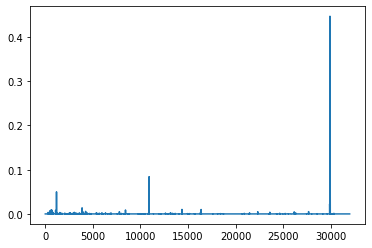

In [41]:
plt.plot(new_distribution[29929].cpu().detach().numpy())

In [11]:
new_distribution = torch.nan_to_num(distributions.cpu() / distributions.cpu().sum(dim=1), 0,0,0)
frequencies, inds = torch.sort(-distributions.sum(dim=1))

In [40]:
inds[30:100]

tensor([29929, 29915, 29945,   470, 29947,   445,   367,   372,   471,   408,
          515, 29953, 29955,   450,   319,   505,   306,   674,   451,   591,
        29901,   287,   599,   385,  1009,   756,   472,   508, 30010, 29891,
          541,   349,   414,   697,   896,  1749,   448,   901,   267,   670,
          262,   315,   714,  1218,  3268,   261,   701,  1048, 29991,   886,
         1058,   350,   916,   270,   368,   671,   975, 29914, 29936,   293,
          317,   738,   383, 29873,   931,  1576,  8059,   590,   607,   273],
       device='cuda:0')

In [18]:
visualize_confused(inds, 0, 1000, 10, new_distribution)

</s>             .                ,                the              and              to               of               
---------------- АН               вид              defin            Lexikon          to               of               
                 \"               },               the              integer          -$               dated            
========         paths            uit              vertex           property         Grund            Pseud            
====             виде             ,                das              and              towards          inhabitants      
<?               .                Batt             crement          datasets         toward           Of               
-------          endpoint         datasets         Sint             Linear           MAN              brow             
------           kre              !}               Nach             layers           incre            dated            
                 emente           oder  

In [58]:
tokenizer.convert_tokens_to_ids(tokenizer.tokenize('graduation'))

[10591, 362]

In [59]:
tokenizer.convert_tokens_to_ids(tokenizer.tokenize('graduatory'))

[10591, 7606]

In [60]:
tokenizer.convert_tokens_to_ids(tokenizer.tokenize('graduate'))

[10591, 403]

In [61]:
tokenizer.convert_tokens_to_ids(tokenizer.tokenize('undergraduate'))

[1090, 5105, 27240]

In [67]:
tokenizer.tokenize('graduate')

['▁gradu', 'ate']

In [70]:
tokenizer.tokenize('grades')

['▁gr', 'ades']

In [66]:
tokenizer.convert_tokens_to_ids(tokenizer.tokenize('postgraduate'))

[1400, 5105, 27240]

In [43]:
distributions[1024].cpu().detach().numpy().sum()

4.0000014

In [15]:
ll = torch.exp( output['logits']-torch.max(output['logits'], 2, keepdims=True).values )

In [18]:
ll1 = torch.exp( output['logits'])/torch.max(output['logits'], 2, keepdims=True).values 
# ll1 /= torch.max(ll1, 2, keepdims=True).values 

In [16]:
index = 19
token_id = input_ids[0,index]
pp = torch.softmax(ll,2)
pp.shape

torch.Size([4, 1024, 32000])

In [20]:
input_ids[0]

tensor([    1,   341, 29873,  ...,   304, 16089, 10388], device='cuda:0')

In [17]:
# Vanilla
token_id = 29882
def normalize(x):
    return x / x.sum()
def get_next_words_global(new_d, token_id, top_k):
    dist = new_d[token_id]
    next_words = torch.argsort(-dist)[:top_k]
    probs = map(lambda x : x.item(), normalize(dist[next_words]))
    next_words = [tokenizer.decode([x]) for x in next_words]
    return list(zip(next_words, probs))

print("Phrase:\t\t\t", repr(tokenizer.decode(input_ids[0,:index])))
print("Next token:\t\t", tokenizer.decode([token_id]))
print("Global distributions:\t", [x[0] for x in get_next_words_global(distributions, token_id, 1000)])
print("Global probs:\t\t", [x[1] for x in get_next_words_global(new_distribution, token_id, 1000)])

Phrase:			 '<s> Mtendere Village was inspired by the vision of Chief Napoleon Dzombe,'
Next token:		 h
Global distributions:	 ['h', 'het', '-', 'H', ',', 'house', 'hab', '.', 'ha', 'e', 'hing', 'hes', 'hours', 'w', 'large', 'k', 'hed', '\n', 'f', 'he', 'b', 'em', 'di', 'y', 'in', 'a', '5', '1', 'am', 's', 'hr', 'hy', '2', 'hem', 'z', 'jud', 'and', 'the', 'm', 'Hz', 'I', 'urt', 'v', 'st', 'and', 'color', 'g', ':', 'how', 'ana', 'c', 'M', 'on', 'ham', 'ur', 'had', 'G', 'cite', 'i', '', 'hh', 'held', 'j', '4', 'eter', 'get', 't', 'her', 'han', 'to', '...', 'har', 'www', 'or', 'sh', 'hi', 'put', 'able', 'H', '7', 'including', 'et', 'ch', 'er', 'jo', 'al', 'quis', '0', 'hum', 'hd', 'reg', ')', 'oh', 'u', 'oll', '/', 'Rep', 'build', 'gh', 'tr', 'o', '(', 'okes', 'of', '9', 'inv', 'like', 'hov', 'p', '6', 'cut', 'lying', 'us', '8', 'the', 'standing', 'through', 'ag', 'ports', 'far', 'hai', 'J', 'Ind', 'ats', 'ical', 'law', "'", '3', 'ad', 'field', 'ray', 'Ar', 'houses', 'h', 'D', 'ay', 'dra',

In [41]:
# - max
def get_next_words_global(new_d, token_id, top_k):
    dist = new_d[token_id]
    next_words = torch.argsort(-dist)[:top_k]
    probs = map(lambda x : x.item(), torch.softmax(dist[next_words], 0))
    next_words = [tokenizer.decode([x]) for x in next_words]
    return list(zip(next_words, probs))

print("Phrase:\t\t\t", repr(tokenizer.decode(input_ids[0,:index])))
print("Next token:\t\t", tokenizer.decode([token_id]))
print("Global distributions:\t", [x[0] for x in get_next_words_global(distributions, token_id, 1000)])
print("Global probs:\t\t", [x[1] for x in get_next_words_global(distributions, token_id, 1000)])

Phrase:			 '<s> Mtendere Village was inspired by the vision of Chief Napoleon Dzombe,'
Next token:		 which
Global distributions:	 ['which', 'and', ',', '.', 'the', 'to', 'that', 'you', 'for', 'but', 'who', 'this', 'as', 'including', 'so', 'from', 'about', 'your', 'over', 'later', '2', 'heat', 'with', 'all', 'of', 'where', 'lub', 'such', 'includes', 'cli', ':', 'in', 'these', 'a', 'my', 'when', ',"', 'or', '1', 'it', 'target', 'designed', 'served', '-', '0', '-', 'links', 'provided', 'especially', 'general', 'software', 'too', 'fi', 'how', '3', 'based', 'while', 'on', 'available', 'even', 'them', 'chemical', 'rub', 'they', 'step', 'making', 'en', 'like', 'because', 'if', '."', 'some', '!', '(', 'fib', '».', 'I', 'our', '5', 're', 'not', 'every', '4', 'allowing', 'l', '&', '', 'always', '6', 'each', 'offering', 'then', 'also', 'at', 'here', 'H', 'created', 'by', 'just', 'both', 'res', 'an', 'featuring', '"', 'r', '7', 'foc', 'their', 'after', '8', 'included', 'flu', 'easy', 'using', 'bef

In [109]:
tokenizer.decode(input_ids[0])

'<s> Mtendere Village was inspired by the vision of Chief Napoleon Dzombe, which he shared with John Blanchard during his first visit to Malawi. Chief Napoleon conveyed the desperate need for a program to intervene and care for the orphans and vulnerable children (OVC) in Malawi, and John committed to help.\nEstablished in honor of John & Lindy’s son, Christopher Blanchard, this particular program is very dear to the Blanchard family. Dana Blanchard, or Mama Dana as she is more commonly referred to at Mtendere, lived on site during the initial development, and she returns each summer to spend the season with her Malawian family. The heart of the program is to be His hands and feet by caring for the children at Mtendere, and meeting their spiritual, physical, academic, and emotional needs.\nMtendere Village is home to 134 children, living in 16 homes with a housemother and several brothers and sisters. This family environment is one that many of the children have never previously experi

In [11]:
new_distributions = torch.softmax(distributions, 1)

In [69]:
s = "For instance, the Schur multiplier of the nonabelian group of order 6 is the trivial group since every Sylow subgroup is cyclic. The Schur multiplier of the elementary abelian group of order 16 is an elementary abelian group of order 64, showing that the multiplier can be strictly larger than the group itself. The Schur multiplier of the quaternion group is trivial, but the Schur multiplier of dihedral 2-groups has order 2."
batch  = tokenizer(s, max_length=len(s.split())+40, padding='max_length', truncation=True)
batch['input_ids']=torch.tensor(batch['input_ids'])
batch['attention_mask']=torch.tensor(batch['attention_mask'])
batch['input_ids'][batch['input_ids']==32000]=2
print(batch)
my_inputids = batch['input_ids'].unsqueeze(0)

{'input_ids': tensor([    1,  1152,  2777, 29892,   278,  1102,   332,  6674,  4926,   310,
          278,  1661,  1107,   713,  2318,   310,  1797, 29871, 29953,   338,
          278, 12604,  2318,  1951,  1432,  8713,   677, 24410,   338,  5094,
        28746, 29889,   450,  1102,   332,  6674,  4926,   310,   278, 22470,
          633, 27185,  2318,   310,  1797, 29871, 29896, 29953,   338,   385,
        22470,   633, 27185,  2318,   310,  1797, 29871, 29953, 29946, 29892,
         6445,   393,   278,  6674,  4926,   508,   367, 18719,  7200,  1135,
          278,  2318,  3528, 29889,   450,  1102,   332,  6674,  4926,   310,
          278,   439, 25744,   291,  2318,   338, 12604, 29892,   541,   278,
         1102,   332,  6674,  4926,   310,   652, 17143,  1705, 29871, 29906,
        29899, 13155,   756,  1797, 29871, 29906, 29889,     2,     2,     2,
            2,     2]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
      

In [75]:
with torch.no_grad():
    my_output = model.forward(my_inputids.to(device), return_dict=True,use_cache=False,output_hidden_states=False)
    visualize_next_word_2(my_output, my_inputids, 0, max(my_inputids.shape)-1, 10)

For            instance       ,              the            Sch            ur             multip         lier           
Unterscheidung the            ,              the            company        olar           complement     lier           
nobody         other          the            if                            ol             decomposition  liers          
everybody      many           in             you            first          r              function       lic            
Hinweis        a              :              a              following      engen          filter         licity         
hopefully      those          if             in             most           eme            fun            rec            
sierp          more           you            when           average        en             -              lications      
Einzeln        ums            I              I              word           ema            product        aram           
Begriffe       this           . 

In [ ]:

The elementary abelian group of order 16.

"The" "elementary abelian group" "of order 16".
  |                  |                 |
The  elementary abelian group     of order 16


